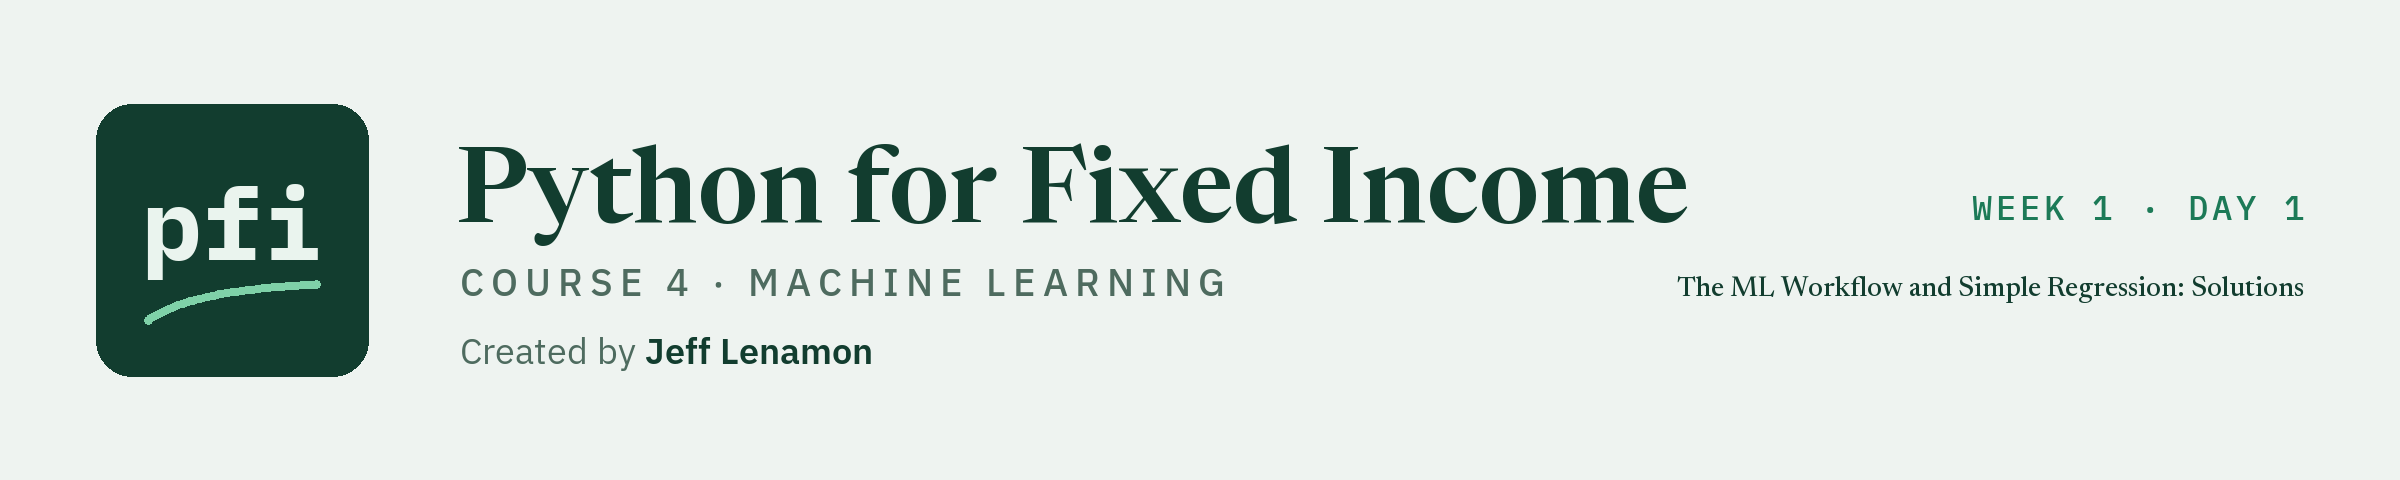

# The ML Workflow and Simple Regression: Solutions

Week 1, Day 1. Worked answers to the exercises. Try each one yourself first.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week1/day1/01_the_ml_workflow_and_simple_regression_solutions.ipynb)

This notebook stands on its own. Its setup writes `mlkit.py` and `test_mlkit.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_01_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_01_2z5ivxee, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the end of today.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics']


## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, makes the course split, fits the section 1.5 line, and defines `check`, a small function that marks your answers.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# the 821 synthetic bonds with their rating score and grade
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")

# the course split and the line fitted on the training rows, as in sections 1.4 and 1.5
X, y = bench[["score"]], bench["oas"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
model = LinearRegression().fit(X_train, y_train)
fitted_test = model.predict(X_test)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Fit the same model on the investment grade bonds only (`grade == "Investment Grade"`). Split them with the course's split (`test_size=0.25`, `random_state=SEED`), fit the line on their training rows, and store its slope in bp per notch in **ex1_slope** and its test MAE in bp in **ex1_test_mae_bp**.

In [6]:
# only the investment grade bonds, then the same split and the same model
investment_grade = bench[bench["grade"] == "Investment Grade"]
Xi_train, Xi_test, yi_train, yi_test = train_test_split(investment_grade[["score"]], investment_grade["oas"],
                                                        test_size=0.25, random_state=SEED)
model_ig = LinearRegression().fit(Xi_train, yi_train)

ex1_slope = model_ig.coef_[0]
ex1_test_mae_bp = mlkit.regression_metrics(yi_test, model_ig.predict(Xi_test))["mae"]
print(f"{len(investment_grade)} bonds: slope {ex1_slope:.1f} bp per notch, test MAE {ex1_test_mae_bp:.1f} bp")

540 bonds: slope 16.7 bp per notch, test MAE 21.8 bp


* 16.7 bp per notch, against 39.1 on all the bonds, and a test MAE of 21.8 bp. Inside investment grade the base spreads rise slowly, so the line is flatter and its misses smaller in bp. The rows are different, so the two MAEs describe different bond sets; neither line is better in general.

In [7]:
check("Exercise 1 the slope", ex1_slope, 16.65602647244852)
check("Exercise 1 the test MAE", ex1_test_mae_bp, 21.826984274920797)

Exercise 1 the slope: correct
Exercise 1 the test MAE: correct


### Exercise 2

Q. Using the line fitted in the first exercise cell (all bonds), compute the test MAE in bp separately for investment grade and high yield test bonds. Store a dictionary of grade (the text in the `grade` column) to MAE in bp, rounded to 1 decimal, in **ex2_mae_by_grade**.

In [8]:
# each test bond's absolute error in bp, beside its grade
test_errors = pd.DataFrame({"grade": bench.loc[X_test.index, "grade"], "error_bp": (y_test - fitted_test).abs()})

ex2_mae_by_grade = {grade: round(float(value), 1) for grade, value in test_errors.groupby("grade")["error_bp"].mean().items()}
print(ex2_mae_by_grade)
print(test_errors["grade"].value_counts().to_string())

{'High Yield': 94.2, 'Investment Grade': 38.9}
grade
Investment Grade    136
High Yield           70


* 38.9 bp for investment grade and 94.2 bp for high yield. One line, one overall MAE of 57.7 bp, and a miss more than twice as large on one side of the scale. An average error over all rows can hide where a model fails; report it by group when the groups differ.

In [9]:
check("Exercise 2 the MAE by grade", ex2_mae_by_grade, {'High Yield': 94.2, 'Investment Grade': 38.9})

Exercise 2 the MAE by grade: correct


### Exercise 3

Q. Add a function to your module. `error_in_bp(y_true, y_fitted)` returns the mean absolute error in bp rounded to 1 decimal, for a desk table; it should call `regression_metrics` rather than compute the error again. Write the docstring first, with the units. Then add `test_error_in_bp_hand_value`, which checks the three hand bonds of `test_regression_metrics_hand_values` (16.7 bp) and that an empty input raises `ValueError`. Run pytest, reload the module, and store `mlkit.error_in_bp(y_test, fitted_test)` in **ex3_test_mae_bp**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [10]:
%%writefile -a mlkit.py


def error_in_bp(y_true, y_fitted) -> float:
    """Mean absolute error in bp, rounded to 1 decimal, for a desk table.

    Inputs: y_true and y_fitted in bp, the same length. Output: regression_metrics(y_true, y_fitted)["mae"]
    rounded to 1 decimal place. Raises ValueError on inputs regression_metrics refuses (empty, not
    one-dimensional, or of different lengths).
    """
    # the course's MAE, then rounded for display
    return round(regression_metrics(y_true, y_fitted)["mae"], 1)

Appending to mlkit.py


In [11]:
%%writefile -a test_mlkit.py


def test_error_in_bp_hand_value():
    # errors 10, -10, 30 bp: the mean absolute error is 16.666... bp, shown as 16.7
    assert mlkit.error_in_bp([100.0, 200.0, 300.0], [110.0, 190.0, 330.0]) == 16.7
    with pytest.raises(ValueError):
        mlkit.error_in_bp([1.0], [])

Appending to test_mlkit.py


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

......                                                                   [100%]
6 passed in 1.25s



In [13]:
# the file changed, so reload before calling the new function
importlib.reload(mlkit)
ex3_test_mae_bp = mlkit.error_in_bp(y_test, fitted_test)
print(f"test MAE of the line: {ex3_test_mae_bp} bp")

test MAE of the line: 57.7 bp


* `6 passed`: today's 5 and the new one.
* 57.7 bp. Rounding belongs at the end, for display: the function rounds what `regression_metrics` returns, and nothing is rounded before the errors are averaged.

In [14]:
check("Exercise 3 error_in_bp on the test rows", ex3_test_mae_bp, 57.7)

Exercise 3 error_in_bp on the test rows: correct


### Exercise 4: AI check

You ask an AI assistant for a function that fits the line and reports its test errors, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit a straight line of OAS (bp) on rating score, and report its errors on rows it did not see.

    Split: train_test_split(X, y, test_size=0.25, random_state=SEED). The line is fitted on the training
    rows only; the test rows are used once, for the reported errors.
    Returns: the fitted model, the labels of the rows it was fitted on, and regression_metrics on the test
    rows (mae and rmse in bp).
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns numbers of the right size, and contains one bug.

* The bug: `LinearRegression().fit(X, y)` fits on **every** bond, the 206 test bonds included, and then reports errors on those same test bonds. The comment makes it sound careful ("as much data as possible"), and the numbers look a little better than section 1.6's: a test MAE of 56.9 bp instead of 57.7 bp. That is what leakage does: the reported error is no longer an error on bonds the model never saw.
* The fix, in the cell below: fit on `X_train, y_train`, and return `X_train.index` as the rows used.

In [15]:
def fit_and_score(bonds):
    """Fit a straight line of OAS (bp) on rating score, and report its errors on rows it did not see.

    Split: train_test_split(X, y, test_size=0.25, random_state=SEED). The line is fitted on the training
    rows only; the test rows are used once, for the reported errors.
    Returns: the fitted model, the labels of the rows it was fitted on, and regression_metrics on the test
    rows (mae and rmse in bp).
    """
    X = bonds[["score"]]
    y = bonds["oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    # the fix: fit on the training rows only, and say so in what comes back
    model = LinearRegression().fit(X_train, y_train)
    metrics = mlkit.regression_metrics(y_test, model.predict(X_test))
    return model, X_train.index, metrics

In [16]:
# the same test, now with mlkit.assert_disjoint itself: it raises if any row is on both sides
ai_model, fit_rows, ai_metrics = fit_and_score(bench)
mlkit.assert_disjoint(fit_rows, X_test.index)
assert abs(ai_model.coef_[0] - model.coef_[0]) < 1e-9, "the slope is not the training rows' slope"
print("fit_and_score fits on the training rows only")

fit_and_score fits on the training rows only


In [17]:
ex4_test_mae_bp = fit_and_score(bench)[2]["mae"]
print(f"fixed: test MAE {ex4_test_mae_bp:.1f} bp, the same as section 1.6")

fixed: test MAE 57.7 bp, the same as section 1.6


* The fixed function gives section 1.6's numbers exactly. Keep the test: a better-looking number is the usual sign of a leak, and a test that checks which rows were used catches it every time.

In [18]:
check("Exercise 4 the fixed function's test MAE", ex4_test_mae_bp, 57.66200909910362)

Exercise 4 the fixed function's test MAE: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```